# Linear vs. tree GP: does the genome-generic architecture actually hold?

Third comparison notebook (docs/design/0003 phase 4) â€” and a different axis than
[0001](0001-tournament-vs-lexicase.ipynb)/[0002](0002-pareto-selection.ipynb): those held the
genome representation fixed (`LinearProgram`) and varied the selection strategy. This one holds
selection fixed (`TournamentSelection`) and varies the representation instead â€”
`LinearProgram` (register machine, `libs/evolve/src/evolve/genome.py`) vs. `TreeProgram`
(Koza-style expression tree, `libs/evolve/src/evolve/tree.py`).

**The main result of this notebook isn't which one wins.** It's that `evolve()`,
`TournamentSelection`, `LexicaseSelection`, and `ParetoSelection` all work completely unchanged
against `TreeProgram` â€” no genome-type branching anywhere in `population.py` or `selection.py`.
That was the actual point of docs/design/0003's "genome must stay generic above the hot loop"
decision, and phase 4 was the first time it was ever tested against a second representation rather
than assumed. See `libs/evolve/tests/test_tree.py` for that proof as executable tests; this
notebook is what running it looks like.

In [1]:
import random
import statistics

import matplotlib.pyplot as plt

from evolve import (
    LinearCrossoverMutation,
    SymbolicRegressionFitness,
    TournamentSelection,
    TreeCrossoverMutation,
    evolve,
    random_program,
    random_tree_program,
)

## The benchmark and the two representations

Same fixed benchmark as every other notebook in this repo. The two representations get a
*comparable but not identical* size budget â€” 12 instructions / 4 registers for linear GP, max
depth 4 for tree GP (up to 31 nodes if full) â€” both fairly typical defaults for each style, not
tuned to favor either. Worth being upfront that this isn't a perfectly controlled comparison; exact
budget parity across genuinely different representations is inherently a little fuzzy.

In [2]:
TARGET = lambda x: x**4 - 3 * x**2 + 2
INPUTS = [i / 5 for i in range(-5, 6)]

POPULATION_SIZE = 60
GENERATIONS = 60
SEEDS = range(10)


def run_linear(seed):
    rng = random.Random(seed)
    population = [random_program(12, 4, num_inputs=1, rng=rng) for _ in range(POPULATION_SIZE)]
    summaries = []
    final_population = evolve(
        population,
        fitness=SymbolicRegressionFitness(target=TARGET, inputs=INPUTS),
        selection=TournamentSelection(k=3),
        variation=LinearCrossoverMutation(mutation_rate=0.1),
        generations=GENERATIONS,
        on_generation=[summaries.append],
        rng=rng,
    )
    return summaries, final_population


def run_tree(seed):
    rng = random.Random(seed)
    population = [random_tree_program(max_depth=4, rng=rng) for _ in range(POPULATION_SIZE)]
    summaries = []
    final_population = evolve(
        population,
        fitness=SymbolicRegressionFitness(target=TARGET, inputs=INPUTS, run=lambda t, x: t.evaluate(x)),
        selection=TournamentSelection(k=3),
        variation=TreeCrossoverMutation(mutation_rate=0.1),
        generations=GENERATIONS,
        on_generation=[summaries.append],
        rng=rng,
    )
    return summaries, final_population


results = {
    "linear": [run_linear(seed) for seed in SEEDS],
    "tree": [run_tree(seed) for seed in SEEDS],
}

## Convergence comparison

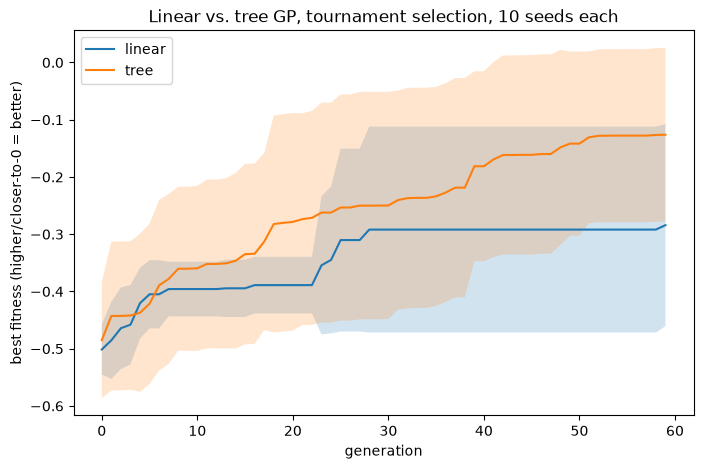

 linear: gen0 mean=-0.5013  final mean=-0.2842  final std=0.1765
   tree: gen0 mean=-0.4851  final mean=-0.1262  final std=0.1515


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, trials in results.items():
    curves = [[s.best_fitness for s in summaries] for summaries, _final in trials]
    by_gen = list(zip(*curves))
    means = [statistics.fmean(gen_values) for gen_values in by_gen]
    stds = [statistics.pstdev(gen_values) for gen_values in by_gen]
    generations = range(len(means))
    ax.plot(generations, means, label=name)
    ax.fill_between(
        generations,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2,
    )

ax.set_xlabel("generation")
ax.set_ylabel("best fitness (higher/closer-to-0 = better)")
ax.set_title(f"Linear vs. tree GP, tournament selection, {len(SEEDS)} seeds each")
ax.legend()
plt.show()

for name, trials in results.items():
    gen0 = statistics.fmean(summaries[0].best_fitness for summaries, _final in trials)
    final = statistics.fmean(summaries[-1].best_fitness for summaries, _final in trials)
    final_std = statistics.pstdev(summaries[-1].best_fitness for summaries, _final in trials)
    print(f"{name:>7}: gen0 mean={gen0:.4f}  final mean={final:.4f}  final std={final_std:.4f}")

Tree GP reaches a clearly better mean final fitness than linear GP here, with tournament selection
held fixed on both sides. A plausible reason: recursive tree evaluation composes naturally (a
subtree computing `x**2` slots directly into a parent that squares it again), while the linear
register machine has to *route* intermediate values through registers correctly, which crossover
can disrupt more easily. That's a hypothesis worth treating skeptically, not a proven explanation
â€” it's exactly the kind of question a second benchmark problem (a different shape than a smooth
single-variable polynomial) should be used to test before trusting it.

## Complexity growth in each representation

Not directly comparable ("effective instructions" and "tree nodes" are different units) â€” shown
side by side, not overlaid, to avoid implying a false equivalence.

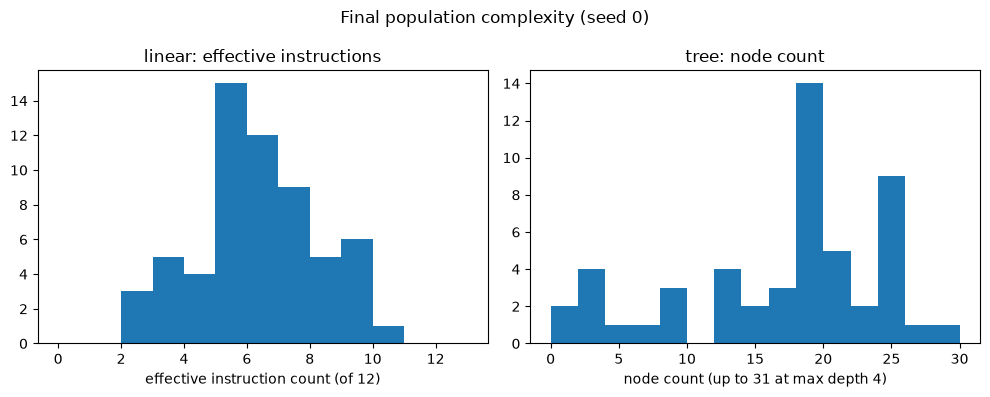

In [4]:
_linear_summaries, linear_final = results["linear"][0]  # seed 0
_tree_summaries, tree_final = results["tree"][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist([p.effective_instruction_count() for p in linear_final], bins=range(0, 14))
ax1.set_title("linear: effective instructions")
ax1.set_xlabel("effective instruction count (of 12)")

ax2.hist([t.node_count() for t in tree_final], bins=range(0, 32, 2))
ax2.set_title("tree: node count")
ax2.set_xlabel("node count (up to 31 at max depth 4)")

fig.suptitle("Final population complexity (seed 0)")
plt.tight_layout()
plt.show()

## Takeaways

- **The architecture claim holds**: swapping `LinearProgram` for `TreeProgram` needed a new genome
  module and a new `VariationStrategy`, and nothing else â€” `evolve()`, `TournamentSelection`,
  `LexicaseSelection`, and `ParetoSelection` were all reused with zero changes. `SymbolicRegressionFitness`
  needed one generalization (an injected `run` callable instead of assuming `.output()`), made
  while adding this representation rather than speculatively beforehand.
  `ParetoSelection`'s `complexity` argument did exactly what it was designed for: `t.node_count()`
  slotted in next to `p.effective_instruction_count()` with no changes to `ParetoSelection` itself.
- **Tree GP outperformed linear GP on this specific benchmark** â€” real, measured, not assumed â€” but
  that's a fact about this one smooth polynomial problem with these specific size budgets, not a
  general claim that tree GP is "better." Different problem shapes could favor either.
- Next per docs/design/0003's roadmap: neuroevolution/ES on a toy simulation â€” the first genome
  type that isn't program-shaped at all (a weight vector), and the first real use of
  `SimulationFitnessEvaluator` instead of dataset-based fitness.